In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import set_config
from sentence_transformers import SentenceTransformer
import warnings

warnings.filterwarnings('ignore')

Data Collecting

In [11]:
print("Load Dataset...")
df = pd.read_csv('D:\Kuliah\Tugas\semester 6\P. Data mining\MusicGeneratingWithSpotify\spotify_data clean.csv')

print(f"Data successfully loaded: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head(10))

Load Dataset...
Data successfully loaded: 8582 rows and 15 columns


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
5,4ccpCcZYseq8VrPMK1EDs0,BLEED,1,2,False,Minzie,46,7218,dark r&b,2NQv9p3ZQW0Ed1LB9enix8,BLEED,2025-10-30,3,single,2.76
6,3QoQ3HqXTAjgEl9LbNMbYp,Te Procuro na Cidade,1,20,False,AZERDK,30,1657,NaN,1PpuOsLjPWshDLxkr0oHeU,Te Procuro na Cidade,2025-10-30,1,single,4.12
7,1YEZbdT417SfolPQzaoHs2,come closer,1,27,False,Rumelis,49,8802,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.53
8,4pZ949nFW5SurwzE0TSe7I,Cupido Vagabundo,1,16,False,Toni dos Anjos,6,475,NaN,60DLQZkzpvDvVfvEC6VOJM,Cupido Vagabundo,2025-10-30,2,single,2.92
9,0L0LgwFZ7UtBnRNQvSBty6,LET’S GO!,1,33,True,PsychoYP,48,154802,"nigerian drill, alté, afro adura, afrobeats, a...",3ARxksm8CspGeAaZZB1v2w,LET’S GO!,2025-10-28,1,single,2.40


Preprocessing

In [12]:
print("Cleaning and process the data...")
df.replace('N/A', np.nan, inplace=True)
df.dropna(subset=['artist_genres', 'track_name', 'artist_name'], inplace=True)

# Put genre into mood ategorize
def assign_mood_nlp(genre_text):
    genre = str(genre_text).lower()
    if any(k in genre for k in ['rock', 'metal', 'punk', 'dance', 'electronic', 'house', 'hip hop']):
        return 'Energetic'
    elif any(k in genre for k in ['pop', 'disco', 'country', 'reggae']):
        return 'Happy'
    elif any(k in genre for k in ['jazz', 'lo-fi', 'acoustic', 'r&b', 'chill', 'blues', 'classical']):
        return 'Chill'
    else:
        return 'Sad'

# DataFrame
df['mood'] = df['artist_genres'].apply(assign_mood_nlp)

# Combine genre and song
df['text_feature'] = df['track_name'] + " - Genre: " + df['artist_genres']

print(f"Preprocessing complete. Total clean data: {df.shape[0]} rows.")

Cleaning and process the data...
Preprocessing complete. Total clean data: 5221 rows.


EDA

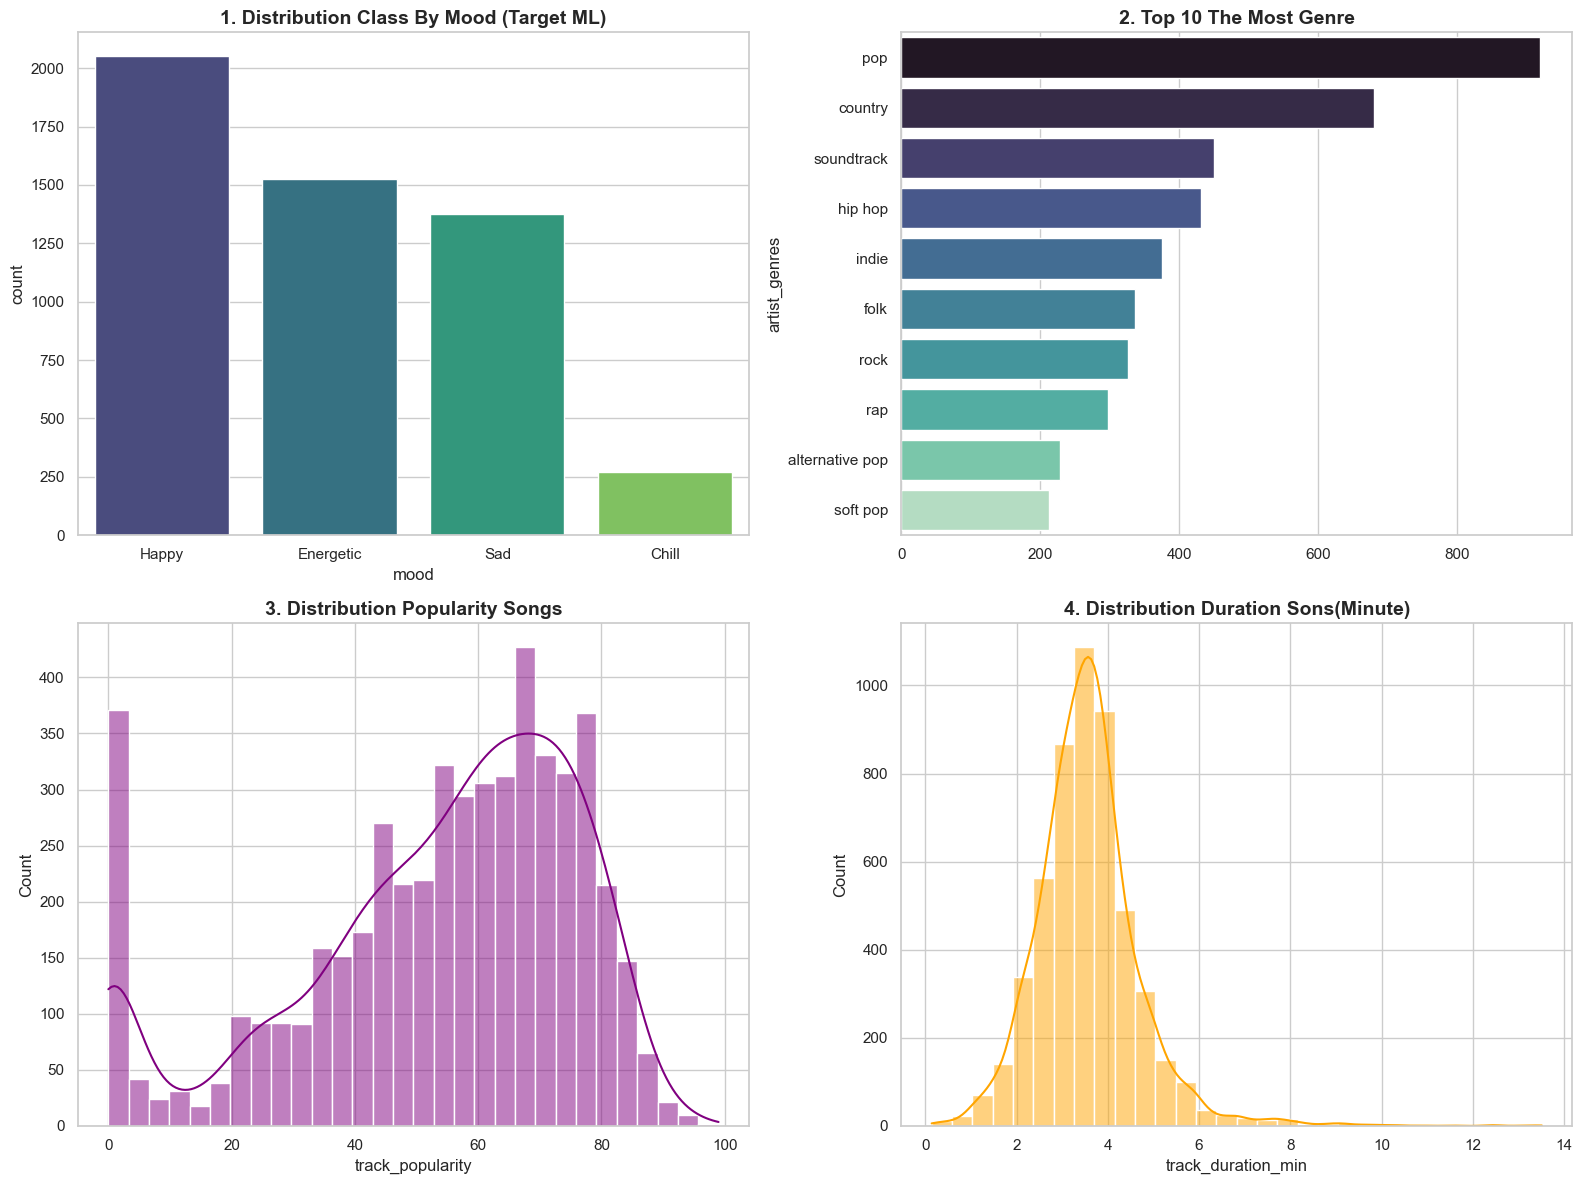

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Grafic 1: Target Distribution (Mood)
sns.countplot(data=df, x='mood', palette='viridis', order=df['mood'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('1. Distribution Class By Mood (Target ML)', fontsize=14, fontweight='bold')

# Grafic 2: Top 10 genre
all_genres = df['artist_genres'].str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako', ax=axes[0, 1])
axes[0, 1].set_title('2. Top 10 The Most Genre', fontsize=14, fontweight='bold')

# Grafik 3: Popularity Distribution
sns.histplot(df['track_popularity'], bins=30, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('3. Distribution Popularity Songs', fontsize=14, fontweight='bold')

# Grafik 4: Duration Distribution
sns.histplot(df['track_duration_min'], bins=30, kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('4. Distribution Duration Sons(Minute)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Pipeline

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import pickle

print("--- Building Machine Learning Pipeline ---")

# Custom Transformer
class TextEmbedder(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model = None

    def fit(self, X, y=None):
        if self.model is None:
            self.model = SentenceTransformer(self.model_name)
        return self

    def transform(self, X):
        return self.model.encode(X, show_progress_bar=False)

# Divided data (80% Train, 20% Test)
df_sample = df.sample(n=2500, random_state=42)
X_text = df_sample['text_feature'].tolist()
y = df_sample['mood']
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Main Pipeline  (Text Embedder -> SVM Classifier)
print("⏳ Craft The Pipeline...")
ml_pipeline = Pipeline([
    ('vectorizer', TextEmbedder()),                                
    ('classifier', SVC(kernel='linear', class_weight='balanced'))  
])

# TRAINING ALL PIPELINE 
print("⏳ Training The Pipeline...")
ml_pipeline.fit(X_train_text, y_train)

# 4. EVALUATION
print("\n--- Result Evaluation of Pipeline ---")
y_pred = ml_pipeline.predict(X_test_text)
akurasi = accuracy_score(y_test, y_pred)

print(f"MODEL ACCURACY: {akurasi * 100:.2f}%\n")
print("Report Details:")
print(classification_report(y_test, y_pred))

--- Building Machine Learning Pipeline ---
⏳ Craft The Pipeline...
⏳ Training The Pipeline...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Result Evaluation of Pipeline ---
MODEL ACCURACY: 93.80%

Report Details:
              precision    recall  f1-score   support

       Chill       0.92      0.88      0.90        26
   Energetic       0.94      0.91      0.92       143
       Happy       0.97      0.96      0.96       198
         Sad       0.90      0.95      0.92       133

    accuracy                           0.94       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.94      0.94      0.94       500



DAG

In [15]:
from sklearn import set_config

set_config(display='diagram')

display(ml_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,model_name,'all-MiniLM-L6-v2'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True


UI

In [16]:
print("--- 🎵 Music Generator UI 🎵 ---")

common_genres = [
    'Pop', 'Rock', 'Hip Hop', 'R&B', 'Country',
    'Jazz', 'Electronic', 'Classical', 'Blues',
    'Indie', 'Metal', 'Reggae', 'Dance'
]
unique_moods = sorted(df['mood'].unique().tolist())

mood_dropdown = widgets.Dropdown(options=['Any'] + unique_moods, value='Any', description='Mood:')
genre_dropdown = widgets.Dropdown(options=['Any'] + common_genres, value='Any', description='Genre:')
generate_button = widgets.Button(description="Generate Music", button_style='success', icon='music')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        selected_genre = genre_dropdown.value
        selected_mood = mood_dropdown.value

        filtered_df = df.copy()

        if selected_genre != 'Any':
            search_term = selected_genre.lower()
            filtered_df = filtered_df[filtered_df['artist_genres'].str.contains(search_term, case=False, na=False)]

        if selected_mood != 'Any':
            filtered_df = filtered_df[filtered_df['mood'] == selected_mood]

        if filtered_df.empty:
            print(f"❌ No songs found for Genre: {selected_genre} and Mood: {selected_mood}. Try another combination!")
        else:
            print(f"✅ AI recommends songs for Genre: '{selected_genre}' & Mood: '{selected_mood}'!\n")

            sample_size = min(3, len(filtered_df))
            recommendations = filtered_df.sample(sample_size)

            for idx, row in recommendations.iterrows():
                track_id = row['track_id']
                spotify_player = f"""
                <div style="margin-bottom: 5px;">
                    <iframe src="https://open.spotify.com/embed/track/{track_id}"
                            width="300" height="80" frameborder="0"
                            allowtransparency="true" allow="encrypted-media">
                    </iframe>
                </div>
                """
                display(HTML(spotify_player))

generate_button.on_click(on_button_clicked)
display(mood_dropdown, genre_dropdown, generate_button, output)

--- 🎵 Music Generator UI 🎵 ---


Dropdown(description='Mood:', options=('Any', 'Chill', 'Energetic', 'Happy', 'Sad'), value='Any')

Dropdown(description='Genre:', options=('Any', 'Pop', 'Rock', 'Hip Hop', 'R&B', 'Country', 'Jazz', 'Electronic…

Button(button_style='success', description='Generate Music', icon='music', style=ButtonStyle())

Output()